Import the dependecies

In [1]:
# =========================
# Data Manipulation
# =========================
import numpy as np
import pandas as pd

# =========================
# Data Visualization
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Data Preprocessing
# =========================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# =========================
# Machine Learning Models
# =========================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# =========================
# Model Evaluation
# =========================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# =========================
# Handling Imbalanced Data (Bonus)
# =========================
from imblearn.over_sampling import SMOTE

# =========================
# Utility Libraries
# =========================
import warnings

# Ignore warning messages
warnings.filterwarnings("ignore")

# =========================
# Visualization Settings
# =========================
plt.style.use("default")

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep"
)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11

# =========================
# Reproducibility
# =========================
RANDOM_STATE = 42

Load Dataset

In [2]:
# Load the dataset to pandas DataFrame
df = pd.read_csv("loan_approval_dataset.csv")
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [3]:
# printing the dimensions(rows x columns) of the dataset
df.shape

(4269, 13)

In [4]:
#printng the first 5 rows of the dataset
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [5]:
#printng the last 5 rows of the dataset
df.tail()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved
4268,4269,1,Graduate,No,9200000,29700000,10,607,17800000,11800000,35700000,12000000,Approved


In [6]:
#getting the information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [7]:
#getting the statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_id,4269.0,2.135000e+03,1.232498e+03,1.0,1068.0,2135.0,3202.0,4269.0
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0


In [8]:
#printing the categorical features
print("Statistical Summary - Categorical Features")
display(df.describe(include="object").T)

Statistical Summary - Categorical Features


,count,unique,top,freq
education,4269,2,Graduate,2144
self_employed,4269,2,Yes,2150
loan_status,4269,2,Approved,2656


In [9]:
#  Feature Overview
feature_summary = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.values,
    "Non-Null Count": df.count().values,
    "Unique Values": df.nunique().values
})

display(feature_summary)

,Feature,Data Type,Non-Null Count,Unique Values
0,loan_id,int64,4269,4269
1,no_of_dependents,int64,4269,6
2,education,object,4269,2
3,self_employed,object,4269,2
4,income_annum,int64,4269,98
5,loan_amount,int64,4269,378
6,loan_term,int64,4269,10
7,cibil_score,int64,4269,601
8,residential_assets_value,int64,4269,278
9,commercial_assets_value,int64,4269,188


In [10]:
#Data Types Analysis
dtype_count = df.dtypes.value_counts()

print("="*50)
print("Data Type Distribution")
print("="*50)

display(dtype_count)

# Separate numerical and categorical features
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(include="object").columns.tolist()

print(f"\nNumerical Features ({len(numerical_features)}):")
print(numerical_features)

print(f"\nCategorical Features ({len(categorical_features)}):")
print(categorical_features)

Data Type Distribution


,count
int64,10
object,3



Numerical Features (10):
['loan_id', ' no_of_dependents', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value']

Categorical Features (3):
[' education', ' self_employed', ' loan_status']


In [11]:
# Missing Value Analysis
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (missing_values / len(df) * 100).round(2)
})

display(missing_summary)

print("\nTotal Missing Values:", missing_values.sum())

,Missing Values,Missing Percentage
loan_id,0,0.0
no_of_dependents,0,0.0
education,0,0.0
self_employed,0,0.0
income_annum,0,0.0
loan_amount,0,0.0
loan_term,0,0.0
cibil_score,0,0.0
residential_assets_value,0,0.0
commercial_assets_value,0,0.0



Total Missing Values: 0


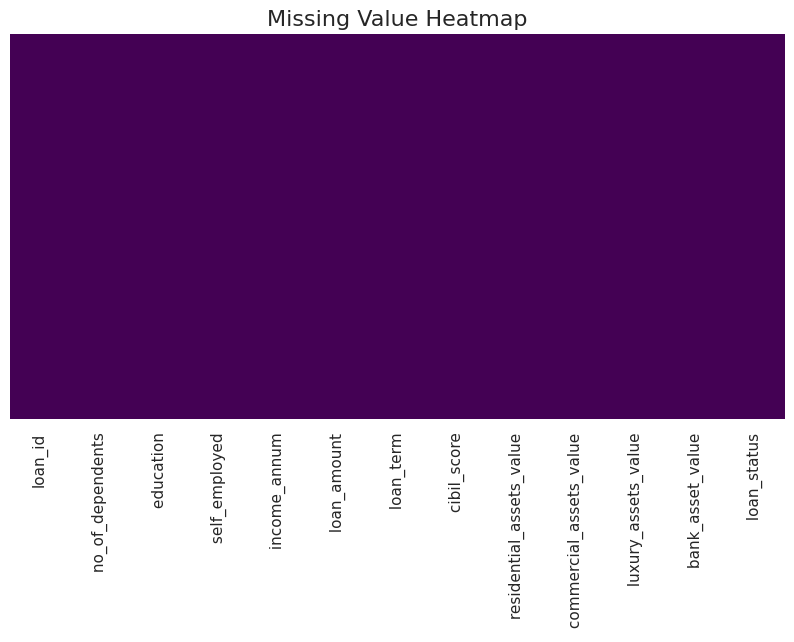

In [12]:
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(),
            cbar=False,
            yticklabels=False,
            cmap="viridis")

plt.title("Missing Value Heatmap")

plt.show()

In [13]:
# Duplicate Analysis
duplicate_rows = df.duplicated().sum()

duplicate_loan_id = df["loan_id"].duplicated().sum()

print("="*50)
print("Duplicate Analysis")
print("="*50)

print(f"Duplicate Rows     : {duplicate_rows}")
print(f"Duplicate Loan IDs : {duplicate_loan_id}")

Duplicate Analysis
Duplicate Rows     : 0
Duplicate Loan IDs : 0


In [14]:
#  Target Variable Identification
target_column = " loan_status"

print(f"Target Variable : {target_column}")

print("\nUnique Classes:")

display(df[target_column].value_counts())

print("\nClass Percentage (%)")

display(
    (
        df[target_column]
        .value_counts(normalize=True)
        *100
    ).round(2)
)

Target Variable :  loan_status

Unique Classes:


,count
loan_status,
Approved,2656
Rejected,1613



Class Percentage (%)


,proportion
loan_status,
Approved,62.22
Rejected,37.78


In [15]:
#Initial Dataset Assessment

print("="*70)
print("Initial Dataset Assessment")
print("="*70)

print(f"Total Samples          : {df.shape[0]:,}")
print(f"Total Features         : {df.shape[1]}")
print(f"Numerical Features     : {len(numerical_features)}")
print(f"Categorical Features   : {len(categorical_features)}")
print(f"Missing Values         : {df.isnull().sum().sum()}")
print(f"Duplicate Rows         : {df.duplicated().sum()}")
print(f"Target Variable        : {target_column}")

print("="*70)

Initial Dataset Assessment
Total Samples          : 4,269
Total Features         : 13
Numerical Features     : 10
Categorical Features   : 3
Missing Values         : 0
Duplicate Rows         : 0
Target Variable        :  loan_status


In [16]:
# Target Variable Analysis

# Count class frequencies
target_counts = df[" loan_status"].value_counts().sort_index()

# Calculate class percentages
target_percentages = (
    df[" loan_status"]
    .value_counts(normalize=True)
    .sort_index() * 100
).round(2)

# Display class distribution
target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage (%)": target_percentages
})

display(target_summary)

,Count,Percentage (%)
loan_status,,
Approved,2656,62.22
Rejected,1613,37.78


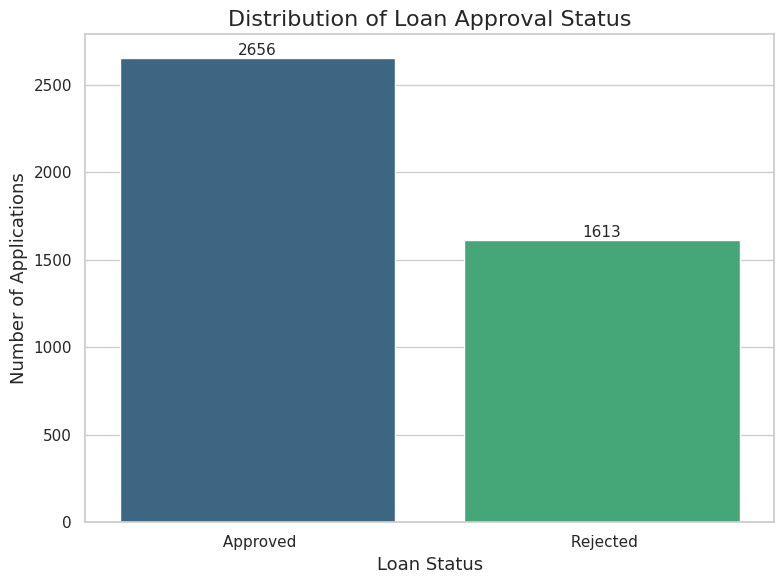

In [17]:
# Target Variable Distribution
plt.figure(figsize=(8,6))

ax = sns.countplot(
    data=df,
    x=" loan_status",
    palette="viridis"
)

# Add count labels
for container in ax.containers:
    ax.bar_label(container, fontsize=11)

plt.title("Distribution of Loan Approval Status", fontsize=16)
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")

plt.tight_layout()
plt.show()

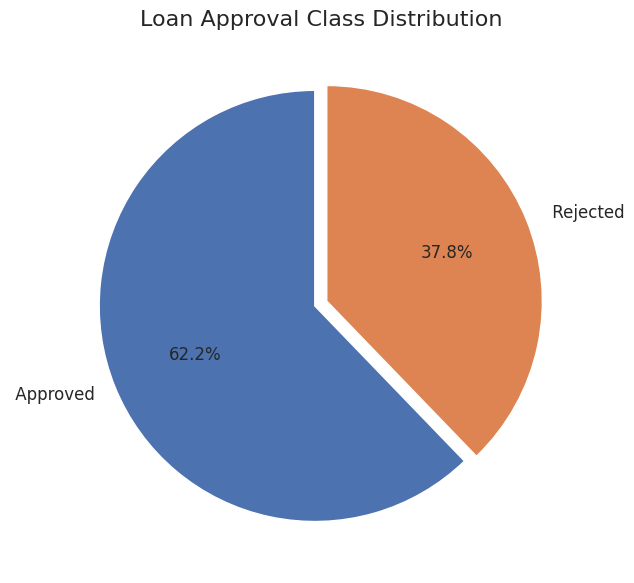

In [18]:
# Percentage Distribution
plt.figure(figsize=(7,7))

plt.pie(
    target_counts,
    labels=target_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=(0.03,0.03),
    textprops={"fontsize":12}
)

plt.title("Loan Approval Class Distribution")

plt.show()

In [19]:
# Class Distribution Summary
majority_class = target_counts.idxmax()
minority_class = target_counts.idxmin()

majority_percentage = target_percentages.max()
minority_percentage = target_percentages.min()

imbalance_ratio = round(
    target_counts.max()/target_counts.min(),
    2
)

print("="*60)
print("Class Distribution Summary")
print("="*60)

print(f"Majority Class        : {majority_class}")
print(f"Minority Class        : {minority_class}")
print(f"Majority Percentage   : {majority_percentage:.2f}%")
print(f"Minority Percentage   : {minority_percentage:.2f}%")
print(f"Imbalance Ratio       : {imbalance_ratio}:1")

print("="*60)

Class Distribution Summary
Majority Class        :  Approved
Minority Class        :  Rejected
Majority Percentage   : 62.22%
Minority Percentage   : 37.78%
Imbalance Ratio       : 1.65:1


In [20]:
# Separate Numerical and Categorical Features

numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include="object").columns.tolist()

# Remove Loan ID (Identifier)
if "loan_id" in numerical_features:
    numerical_features.remove("loan_id")

print(f"Numerical Features ({len(numerical_features)}):")
print(numerical_features)

print("\nCategorical Features ({})".format(len(categorical_features)))
print(categorical_features)

Numerical Features (9):
[' no_of_dependents', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value']

Categorical Features (3)
[' education', ' self_employed', ' loan_status']


In [21]:
# Summary Statistics
summary_stats = df[numerical_features].describe().T

summary_stats["Median"] = df[numerical_features].median()

summary_stats["Skewness"] = df[numerical_features].skew()

summary_stats["Missing"] = df[numerical_features].isnull().sum()

summary_stats = summary_stats[
    [
        "count",
        "mean",
        "50%",
        "Median",
        "std",
        "min",
        "max",
        "Skewness",
        "Missing"
    ]
]

display(summary_stats)

,count,mean,50%,Median,std,min,max,Skewness,Missing
no_of_dependents,4269.0,2.498712e+00,3.0,3.0,1.695910e+00,0.0,5.0,-0.017971,0
income_annum,4269.0,5.059124e+06,5100000.0,5100000.0,2.806840e+06,200000.0,9900000.0,-0.012814,0
loan_amount,4269.0,1.513345e+07,14500000.0,14500000.0,9.043363e+06,300000.0,39500000.0,0.308724,0
loan_term,4269.0,1.090045e+01,10.0,10.0,5.709187e+00,2.0,20.0,0.036359,0
cibil_score,4269.0,5.999361e+02,600.0,600.0,1.724304e+02,300.0,900.0,-0.009039,0
residential_assets_value,4269.0,7.472617e+06,5600000.0,5600000.0,6.503637e+06,-100000.0,29100000.0,0.978451,0
commercial_assets_value,4269.0,4.973155e+06,3700000.0,3700000.0,4.388966e+06,0.0,19400000.0,0.957791,0
luxury_assets_value,4269.0,1.512631e+07,14600000.0,14600000.0,9.103754e+06,300000.0,39200000.0,0.322208,0
bank_asset_value,4269.0,4.976692e+06,4600000.0,4600000.0,3.250185e+06,0.0,14700000.0,0.560725,0


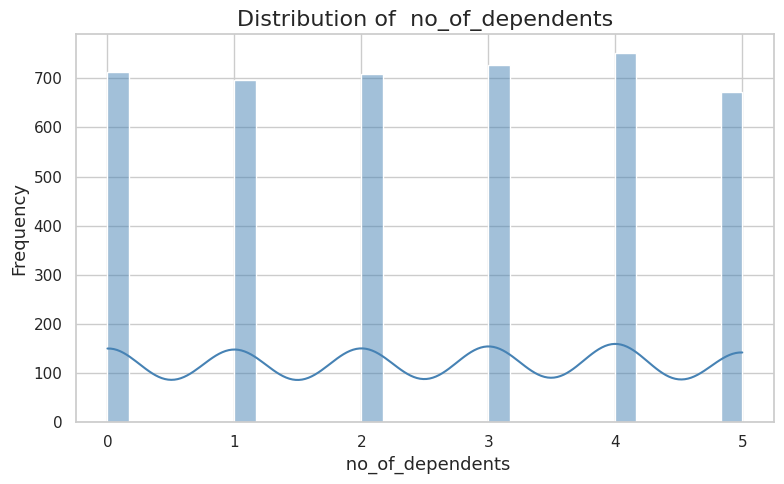

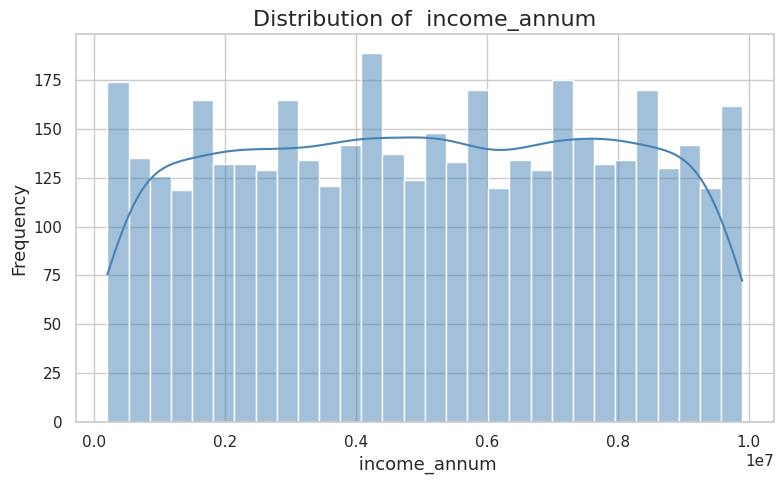

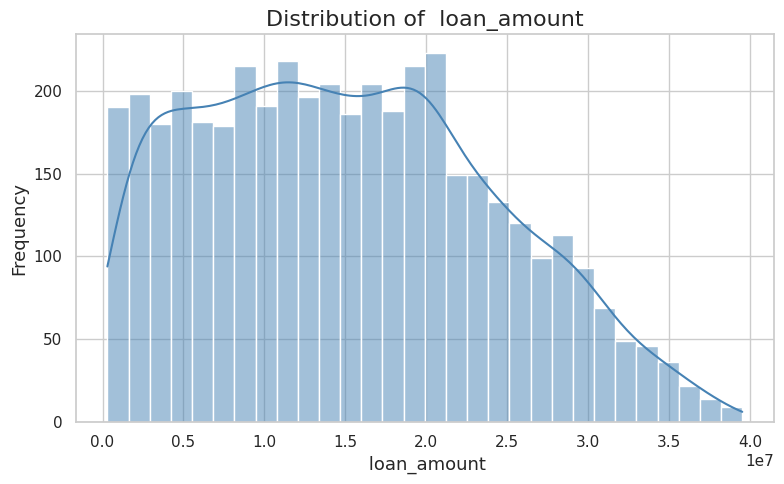

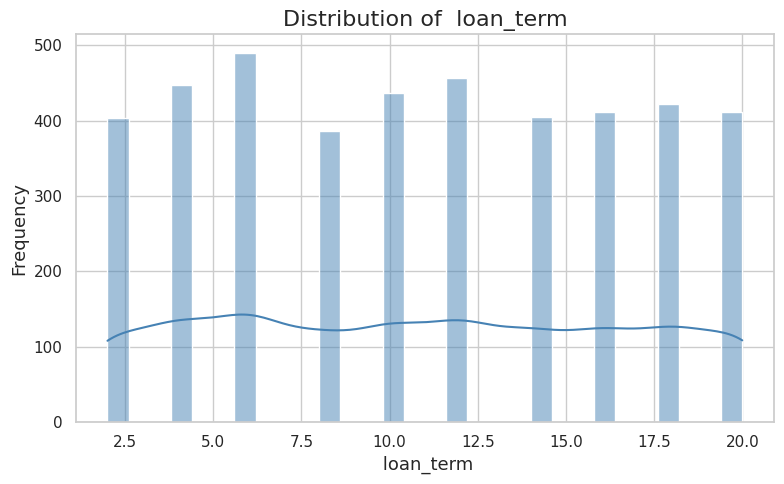

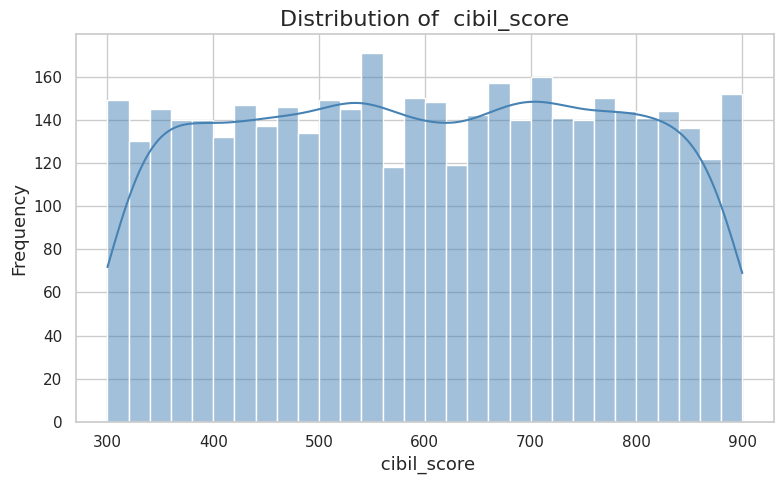

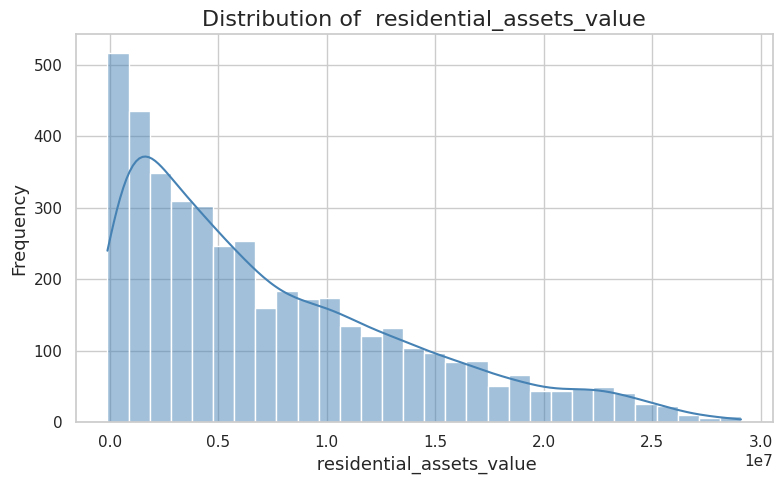

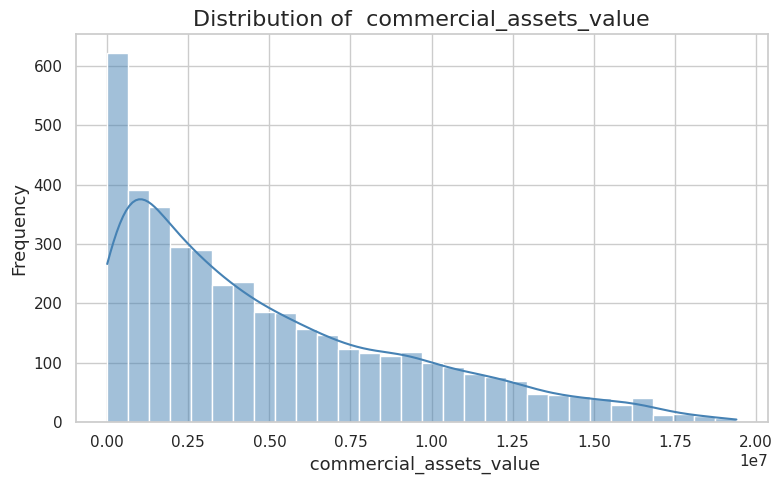

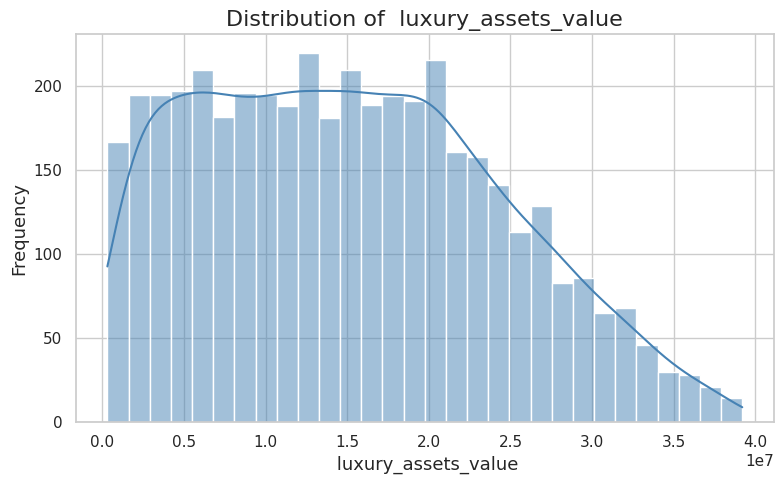

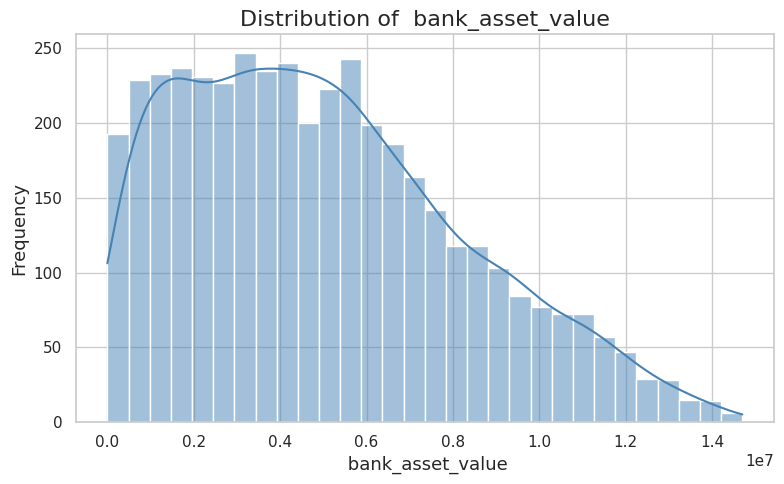

In [22]:
# Numerical Feature Distributions
for feature in numerical_features:

    plt.figure(figsize=(8,5))

    sns.histplot(
        df[feature],
        kde=True,
        bins=30,
        color="steelblue"
    )

    plt.title(f"Distribution of {feature}")

    plt.xlabel(feature)

    plt.ylabel("Frequency")

    plt.tight_layout()

    plt.show()

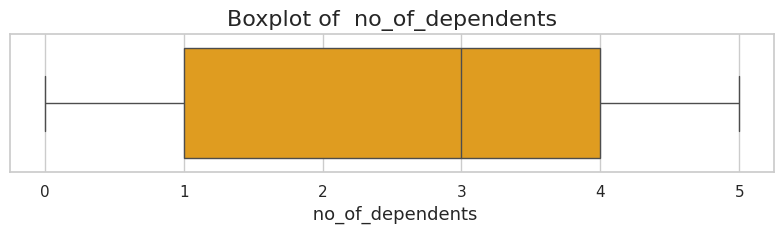

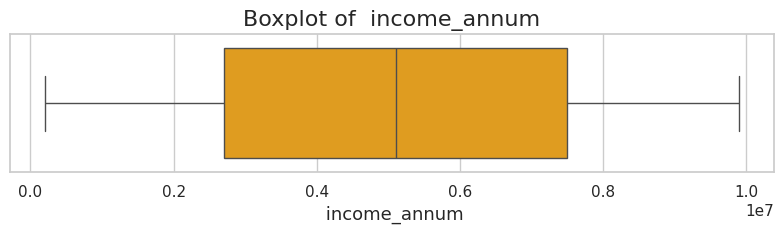

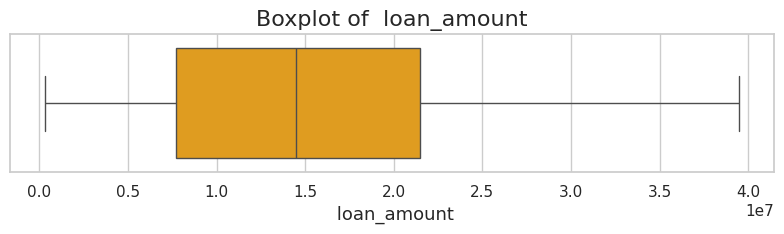

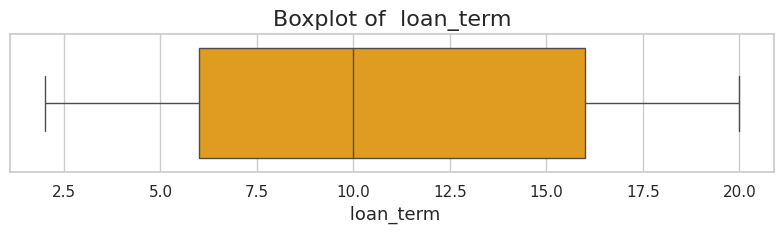

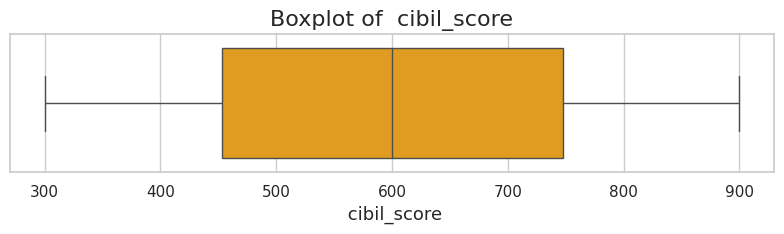

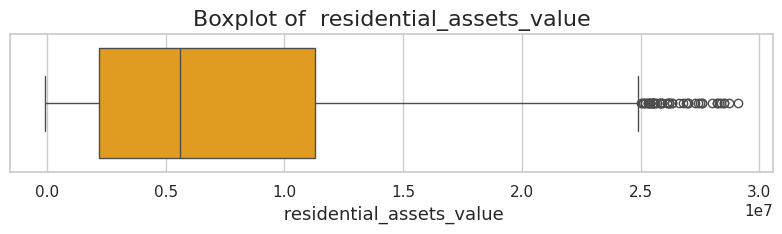

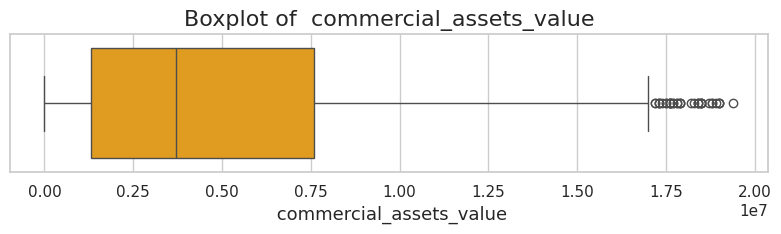

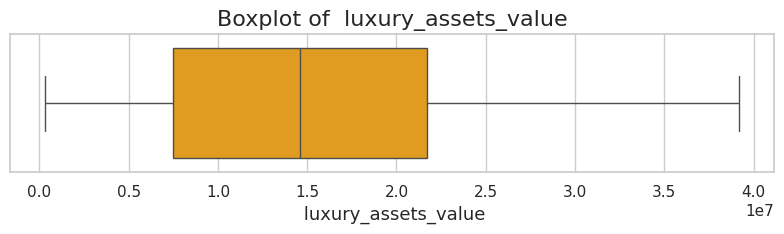

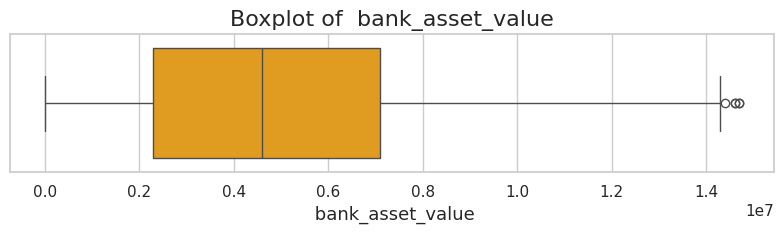

In [23]:
# Outlier Detection
for feature in numerical_features:

    plt.figure(figsize=(8,2.5))

    sns.boxplot(
        x=df[feature],
        color="orange"
    )

    plt.title(f"Boxplot of {feature}")

    plt.tight_layout()

    plt.show()

In [24]:
# Skewness Analysis
skewness = df[numerical_features].skew()

skew_table = pd.DataFrame({
    "Feature": skewness.index,
    "Skewness": skewness.values
})

def skew_type(value):

    if abs(value) < 0.5:
        return "Approximately Symmetric"

    elif abs(value) < 1:
        return "Moderately Skewed"

    else:
        return "Highly Skewed"

skew_table["Interpretation"] = skew_table["Skewness"].apply(skew_type)

display(skew_table.sort_values(by="Skewness", ascending=False))

,Feature,Skewness,Interpretation
5,residential_assets_value,0.978451,Moderately Skewed
6,commercial_assets_value,0.957791,Moderately Skewed
8,bank_asset_value,0.560725,Moderately Skewed
7,luxury_assets_value,0.322208,Approximately Symmetric
2,loan_amount,0.308724,Approximately Symmetric
3,loan_term,0.036359,Approximately Symmetric
4,cibil_score,-0.009039,Approximately Symmetric
1,income_annum,-0.012814,Approximately Symmetric
0,no_of_dependents,-0.017971,Approximately Symmetric


In [25]:
# Frequency Distribution
for feature in categorical_features:

    print("="*60)

    print(f"{feature}")

    print("="*60)

    display(df[feature].value_counts())

 education


,count
education,
Graduate,2144
Not Graduate,2125


 self_employed


,count
self_employed,
Yes,2150
No,2119


 loan_status


,count
loan_status,
Approved,2656
Rejected,1613


In [26]:
# Percentage Distribution
for feature in categorical_features:

    print("="*60)

    print(f"{feature}")

    print("="*60)

    display(
        (
            df[feature]
            .value_counts(normalize=True)
            *100
        ).round(2)
    )

 education


,proportion
education,
Graduate,50.22
Not Graduate,49.78


 self_employed


,proportion
self_employed,
Yes,50.36
No,49.64


 loan_status


,proportion
loan_status,
Approved,62.22
Rejected,37.78


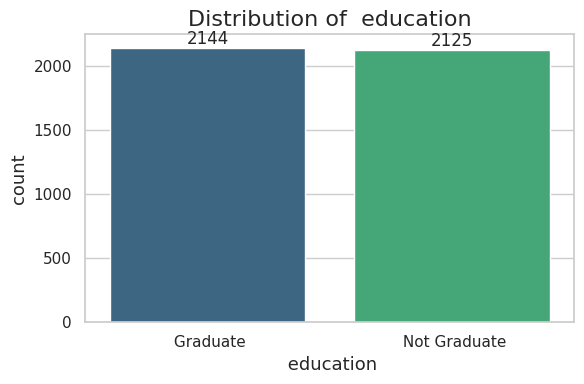

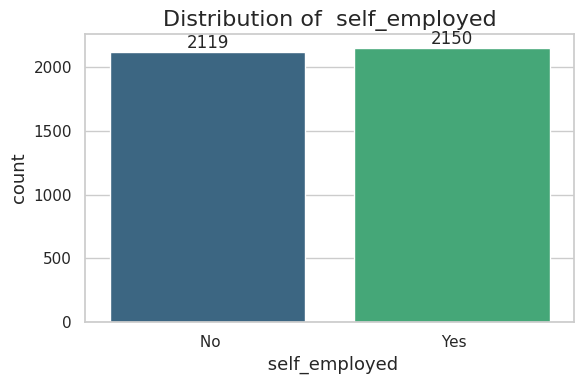

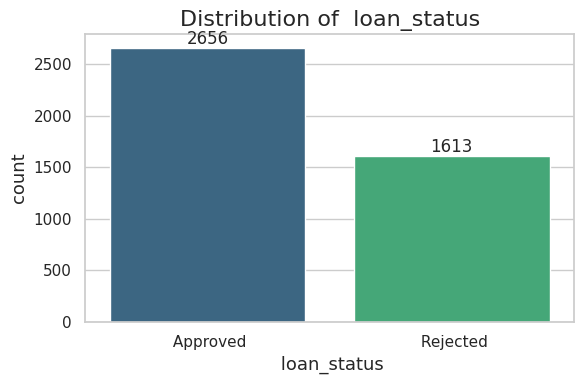

In [27]:
# Categorical Feature Visualization
for feature in categorical_features:

    plt.figure(figsize=(6,4))

    ax = sns.countplot(
        data=df,
        x=feature,
        palette="viridis"
    )

    for container in ax.containers:
        ax.bar_label(container)

    plt.title(f"Distribution of {feature}")

    plt.tight_layout()

    plt.show()

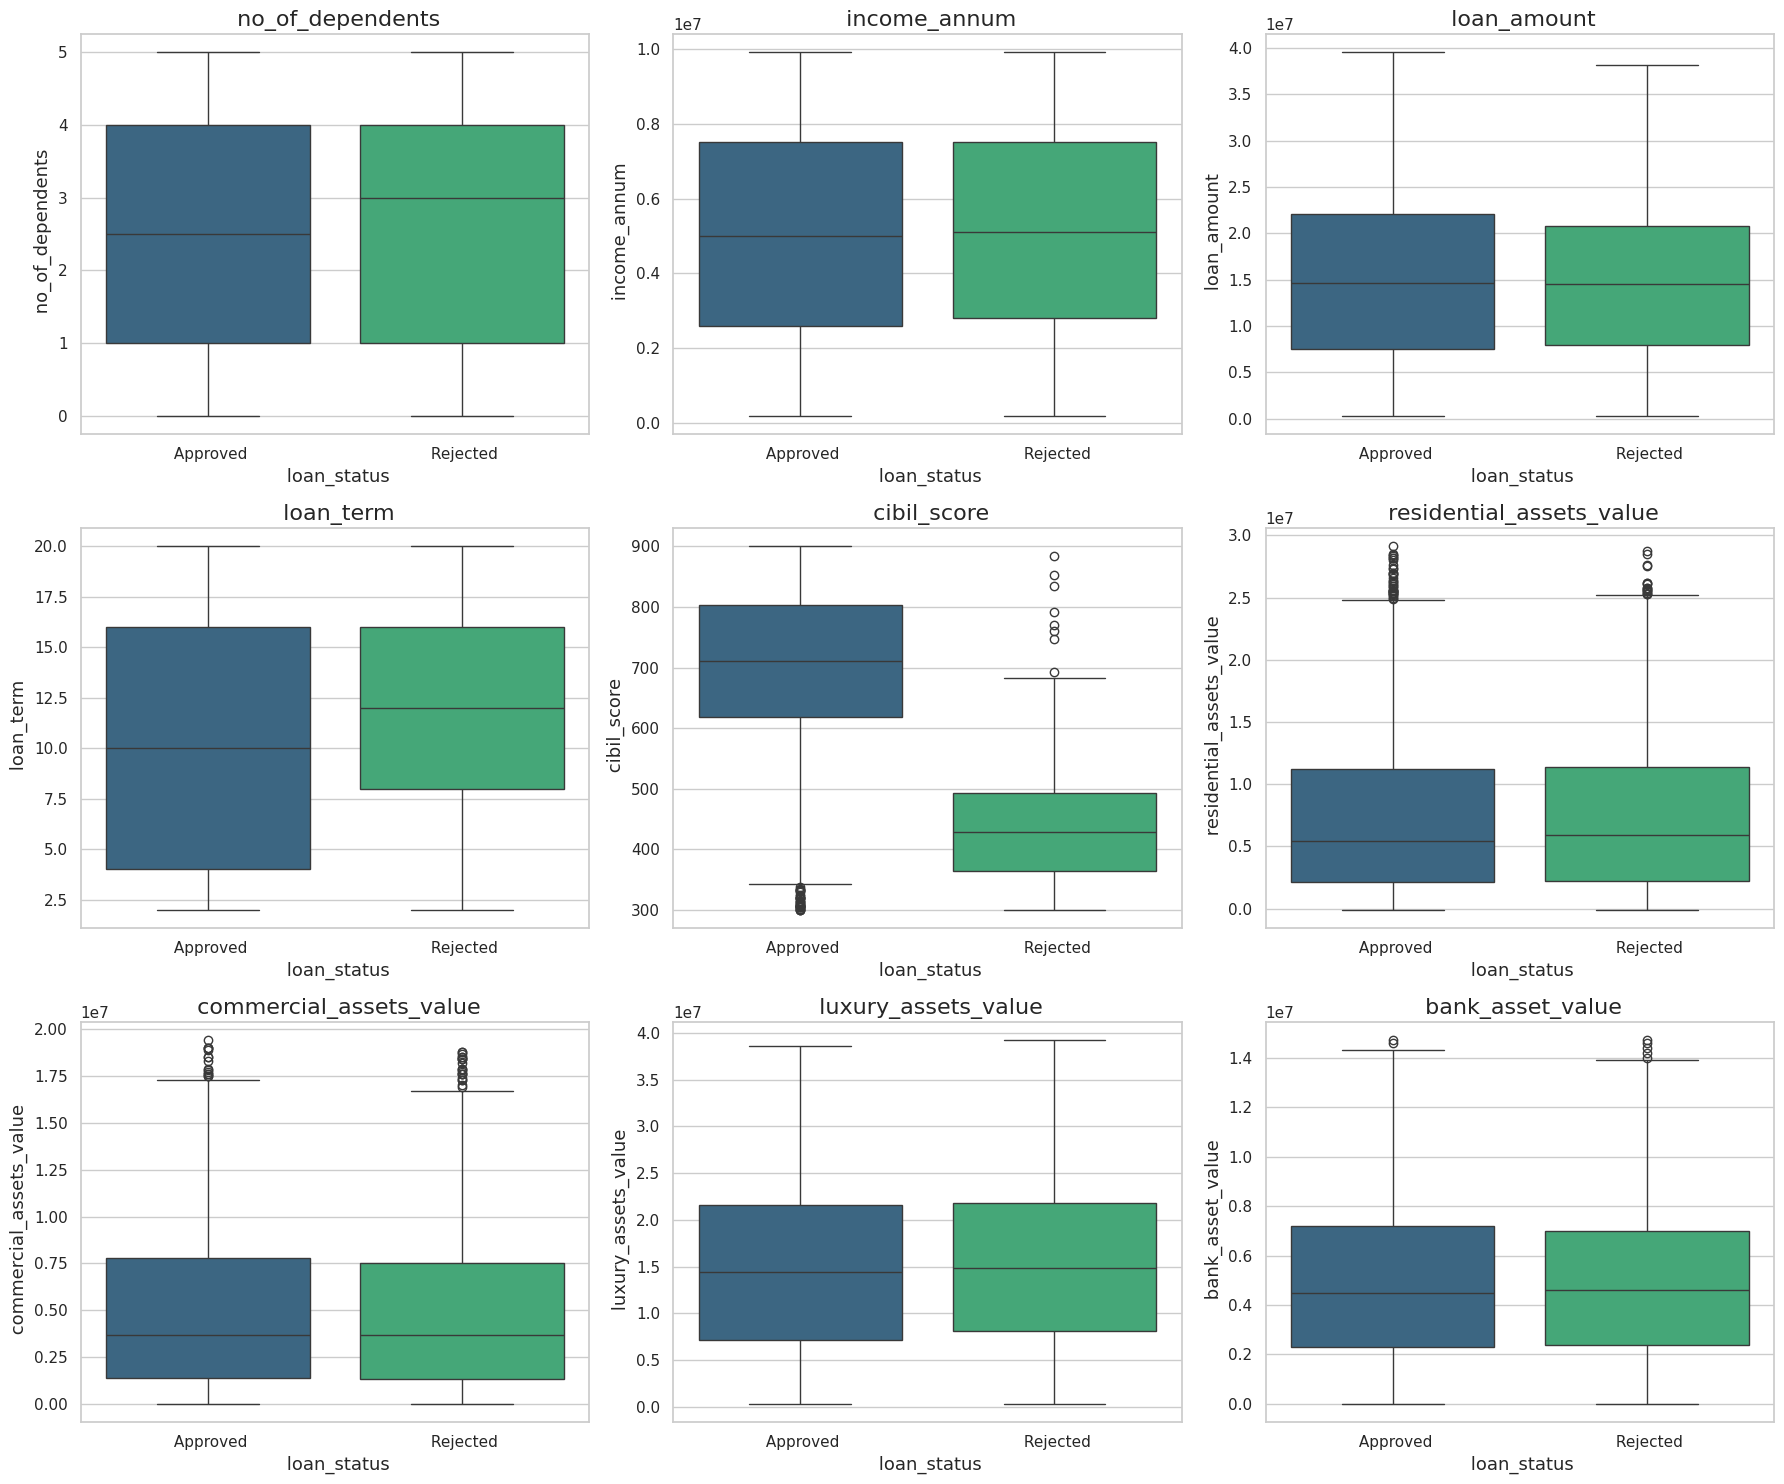

In [28]:
# Numerical Features vs Loan Status
fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(18,15)
)

axes = axes.flatten()

for i, feature in enumerate(numerical_features):

    sns.boxplot(
        data=df,
        x=" loan_status",
        y=feature,
        palette="viridis",
        ax=axes[i]
    )

    axes[i].set_title(feature)

# Remove unused subplot(s)
for j in range(len(numerical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [29]:
# Mean Comparison
numerical_summary = (
    df
    .groupby(" loan_status")[numerical_features]
    .mean()
    .T
)

display(numerical_summary)

loan_status,Approved,Rejected
no_of_dependents,2.474774e+00,2.538128e+00
income_annum,5.025904e+06,5.113825e+06
loan_amount,1.524725e+07,1.494606e+07
loan_term,1.039759e+01,1.172846e+01
cibil_score,7.034620e+02,4.294681e+02
residential_assets_value,7.399812e+06,7.592498e+06
commercial_assets_value,5.001355e+06,4.926720e+06
luxury_assets_value,1.501660e+07,1.530694e+07
bank_asset_value,4.959526e+06,5.004960e+06


In [30]:
# Median Comparison
median_summary = (
    df
    .groupby(" loan_status")[numerical_features]
    .median()
    .T
)

display(median_summary)

loan_status,Approved,Rejected
no_of_dependents,2.5,3.0
income_annum,5000000.0,5100000.0
loan_amount,14600000.0,14500000.0
loan_term,10.0,12.0
cibil_score,711.0,429.0
residential_assets_value,5400000.0,5900000.0
commercial_assets_value,3700000.0,3700000.0
luxury_assets_value,14400000.0,14800000.0
bank_asset_value,4500000.0,4600000.0


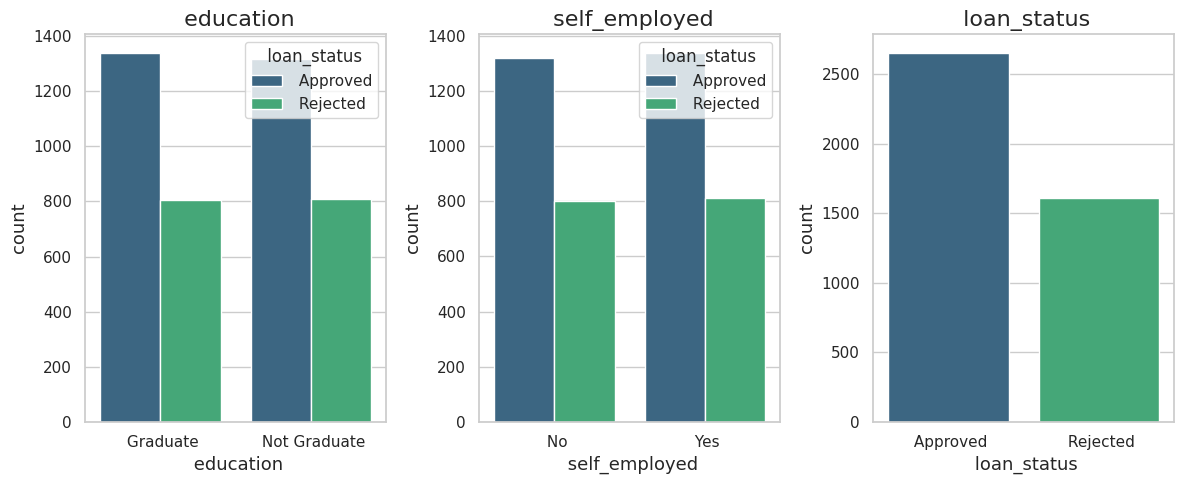

In [31]:
# visualize
# Categorical Features vs Loan Status

categorical_without_target = [
    col for col in categorical_features
    if col != "loan_status"
]

fig, axes = plt.subplots(
    1,
    len(categorical_without_target),
    figsize=(12,5)
)

if len(categorical_without_target) == 1:
    axes = [axes]

for ax, feature in zip(axes, categorical_without_target):

    sns.countplot(
        data=df,
        x=feature,
        hue=" loan_status",
        palette="viridis",
        ax=ax
    )

    ax.set_title(feature)

plt.tight_layout()

plt.show()

In [32]:
# Percentage Distribution
for feature in categorical_without_target:

    print("="*70)

    print(feature)

    print("="*70)

    display(

        pd.crosstab(

            df[feature],

            df[" loan_status"],

            normalize="index"

        ).round(3)*100

    )

 education


loan_status,Approved,Rejected
education,,
Graduate,62.5,37.5
Not Graduate,62.0,38.0


 self_employed


loan_status,Approved,Rejected
self_employed,,
No,62.2,37.8
Yes,62.2,37.8


 loan_status


loan_status,Approved,Rejected
loan_status,,
Approved,100.0,0.0
Rejected,0.0,100.0


In [33]:
# Frequency Crosstab
for feature in categorical_without_target:

    print("="*70)

    print(feature)

    print("="*70)

    display(

        pd.crosstab(

            df[feature],

            df[" loan_status"]

        )

    )

 education


loan_status,Approved,Rejected
education,,
Graduate,1339,805
Not Graduate,1317,808


 self_employed


loan_status,Approved,Rejected
self_employed,,
No,1318,801
Yes,1338,812


 loan_status


loan_status,Approved,Rejected
loan_status,,
Approved,2656,0
Rejected,0,1613


In [34]:
# 5.4.1 Correlation Matrix
# Compute correlation matrix for numerical features
correlation_matrix = df[numerical_features].corr(method="pearson")

display(correlation_matrix.round(2))

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
no_of_dependents,1.00,0.01,-0.00,-0.02,-0.01,0.01,-0.00,0.00,0.01
income_annum,0.01,1.00,0.93,0.01,-0.02,0.64,0.64,0.93,0.85
loan_amount,-0.00,0.93,1.00,0.01,-0.02,0.59,0.60,0.86,0.79
loan_term,-0.02,0.01,0.01,1.00,0.01,0.01,-0.01,0.01,0.02
cibil_score,-0.01,-0.02,-0.02,0.01,1.00,-0.02,-0.00,-0.03,-0.02
residential_assets_value,0.01,0.64,0.59,0.01,-0.02,1.00,0.41,0.59,0.53
commercial_assets_value,-0.00,0.64,0.60,-0.01,-0.00,0.41,1.00,0.59,0.55
luxury_assets_value,0.00,0.93,0.86,0.01,-0.03,0.59,0.59,1.00,0.79
bank_asset_value,0.01,0.85,0.79,0.02,-0.02,0.53,0.55,0.79,1.00


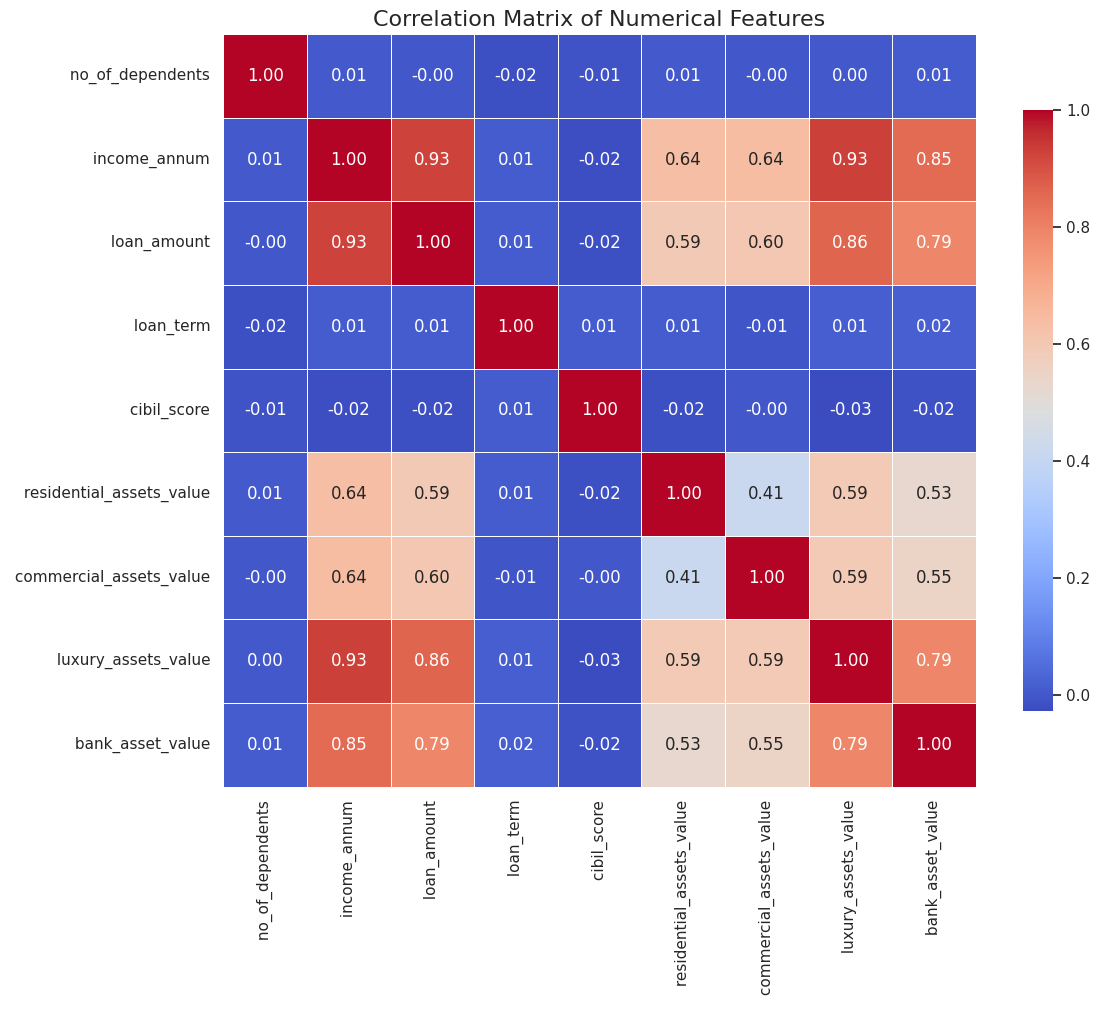

In [35]:
# Correlation Heatmap
plt.figure(figsize=(12,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink":0.8}
)

plt.title("Correlation Matrix of Numerical Features", fontsize=16)

plt.tight_layout()

# Save the figure
plt.savefig(
    "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
# Strong Correlation Detection

corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

strong_corr = corr_pairs[
    corr_pairs["Correlation"].abs() >= 0.70
].sort_values(
    by="Correlation",
    ascending=False
)

print("Strong Correlations (|r| ≥ 0.70)\n")

display(strong_corr)

Strong Correlations (|r| ≥ 0.70)



,Feature 1,Feature 2,Correlation
13,income_annum,luxury_assets_value,0.929145
8,income_annum,loan_amount,0.927470
19,loan_amount,luxury_assets_value,0.860914
14,income_annum,bank_asset_value,0.851093
35,luxury_assets_value,bank_asset_value,0.788517
20,loan_amount,bank_asset_value,0.788122


In [37]:
# Moderate Correlation Detection
moderate_corr = corr_pairs[
    (corr_pairs["Correlation"].abs() >= 0.40) &
    (corr_pairs["Correlation"].abs() < 0.70)
].sort_values(
    by="Correlation",
    ascending=False
)

print("Moderate Correlations (0.40 ≤ |r| < 0.70)\n")

display(moderate_corr)

Moderate Correlations (0.40 ≤ |r| < 0.70)



,Feature 1,Feature 2,Correlation
12,income_annum,commercial_assets_value,0.640328
11,income_annum,residential_assets_value,0.636841
18,loan_amount,commercial_assets_value,0.603188
17,loan_amount,residential_assets_value,0.594596
33,commercial_assets_value,luxury_assets_value,0.591128
31,residential_assets_value,luxury_assets_value,0.590932
34,commercial_assets_value,bank_asset_value,0.548576
32,residential_assets_value,bank_asset_value,0.527418
30,residential_assets_value,commercial_assets_value,0.414786


In [38]:
# Weak Correlation Detection
weak_corr = corr_pairs[
    corr_pairs["Correlation"].abs() < 0.40
].sort_values(
    by="Correlation",
    ascending=False
)

print("Weak Correlations (|r| < 0.40)\n")

display(weak_corr.head(15))

Weak Correlations (|r| < 0.40)



,Feature 1,Feature 2,Correlation
25,loan_term,bank_asset_value,0.017177
24,loan_term,luxury_assets_value,0.012490
9,income_annum,loan_term,0.011488
7,no_of_dependents,bank_asset_value,0.011163
15,loan_amount,loan_term,0.008437
22,loan_term,residential_assets_value,0.008016
21,loan_term,cibil_score,0.007810
4,no_of_dependents,residential_assets_value,0.007376
0,no_of_dependents,income_annum,0.007266
6,no_of_dependents,luxury_assets_value,0.002817


In [39]:
#Outlier Detection Using IQR Method
outlier_summary = []

for feature in numerical_features:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": feature,
        "Outliers": len(outliers),
        "Percentage (%)": round(len(outliers) / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,Feature,Outliers,Percentage (%)
0,no_of_dependents,0,0.00
1,income_annum,0,0.00
2,loan_amount,0,0.00
3,loan_term,0,0.00
4,cibil_score,0,0.00
5,residential_assets_value,52,1.22
6,commercial_assets_value,37,0.87
7,luxury_assets_value,0,0.00
8,bank_asset_value,5,0.12


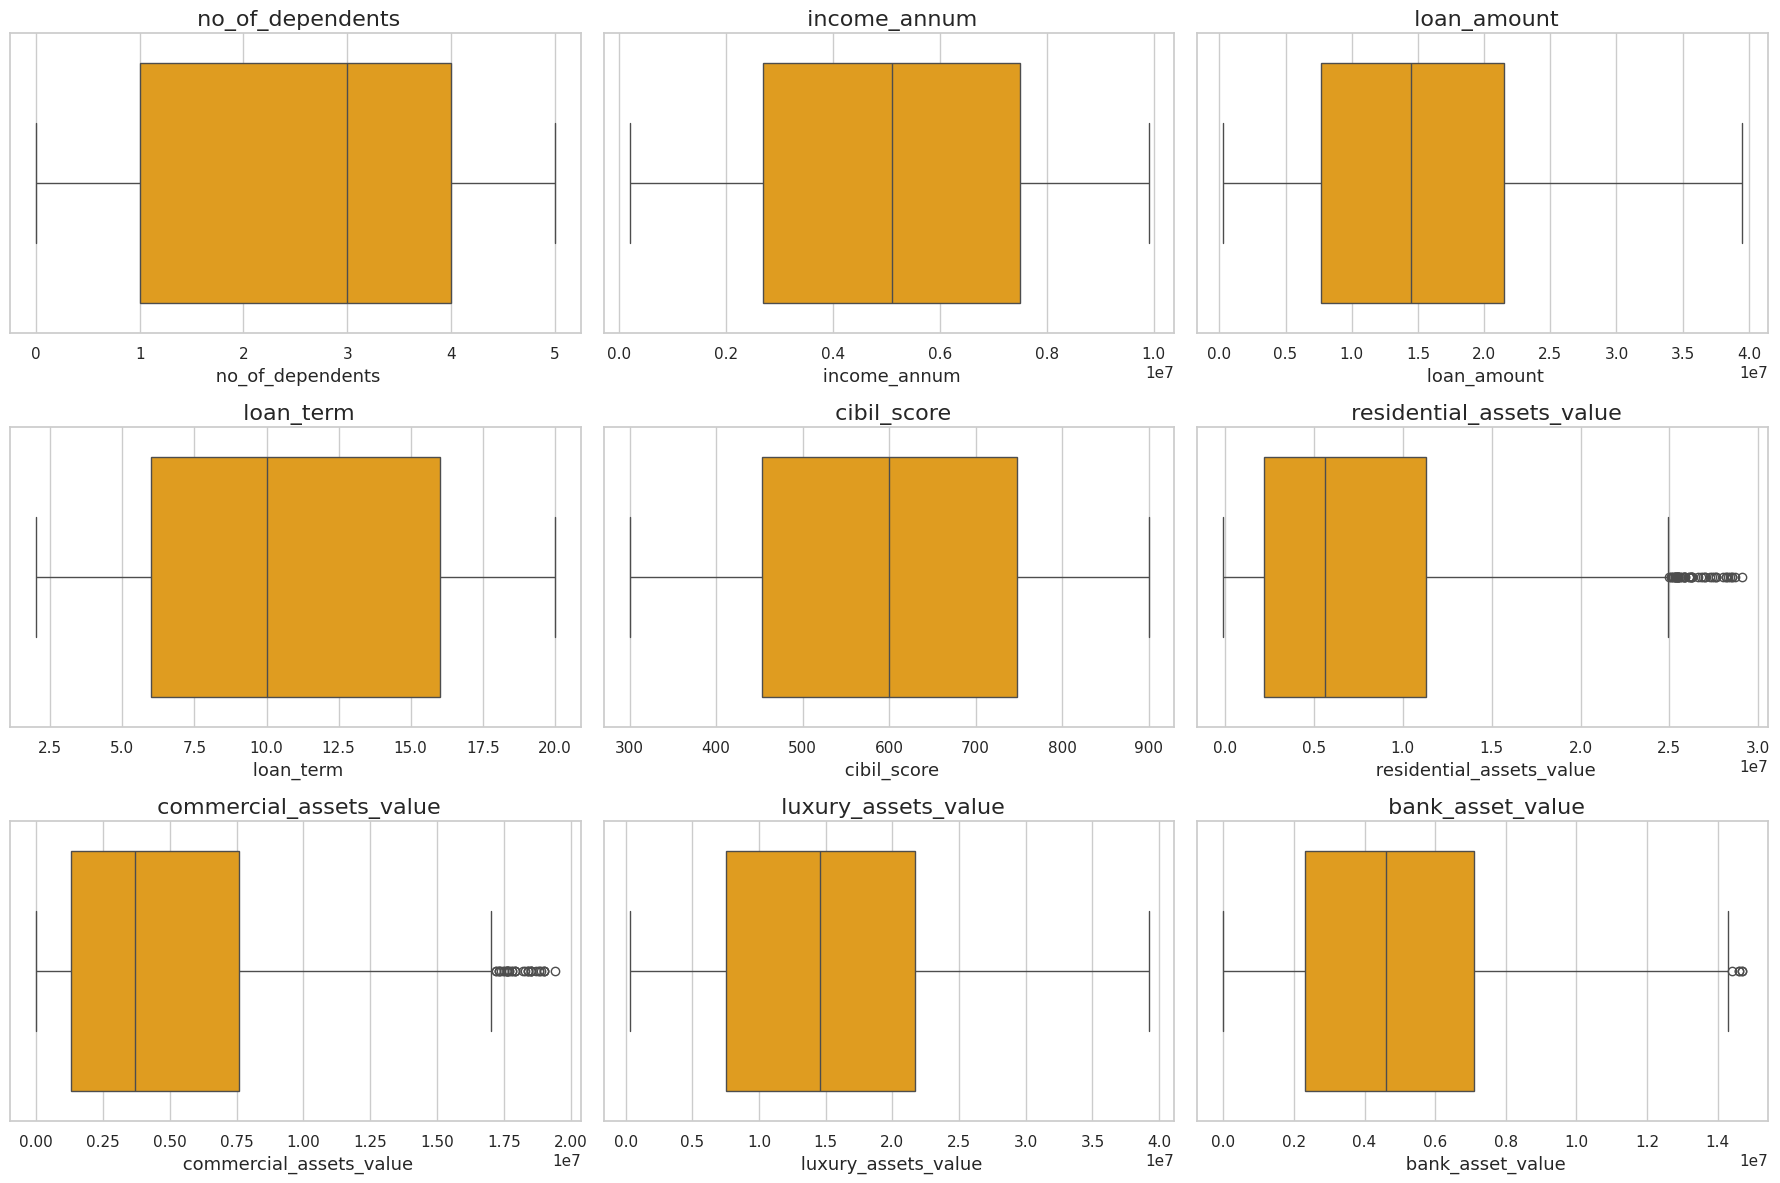

In [40]:
# Boxplots for Outlier Visualization
fig, axes = plt.subplots(
    3,
    3,
    figsize=(18, 12)
)

axes = axes.flatten()

for i, feature in enumerate(numerical_features):

    sns.boxplot(
        x=df[feature],
        color="orange",
        ax=axes[i]
    )

    axes[i].set_title(feature)

for j in range(len(numerical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.show()

In [41]:
# Features Ranked by Outlier Percentage

outlier_summary = outlier_summary.sort_values(
    by="Percentage (%)",
    ascending=False
)

display(outlier_summary)

,Feature,Outliers,Percentage (%)
5,residential_assets_value,52,1.22
6,commercial_assets_value,37,0.87
8,bank_asset_value,5,0.12
0,no_of_dependents,0,0.00
1,income_annum,0,0.00
4,cibil_score,0,0.00
3,loan_term,0,0.00
2,loan_amount,0,0.00
7,luxury_assets_value,0,0.00


## Outlier Analysis

The Interquartile Range (IQR) method was employed to identify observations lying beyond the conventional 1.5 × IQR boundaries.

Several numerical variables, particularly those representing applicant income, loan amount, and asset values, contain observations that are statistically classified as outliers.

However, these observations should be interpreted cautiously.

Unlike manufacturing or sensor datasets where outliers often indicate measurement errors, financial datasets naturally contain individuals with substantially higher income levels and asset ownership.

Consequently, these observations represent legitimate business cases rather than erroneous data points.

-----

## Business Interpretation

From a banking perspective, applicants with exceptionally high annual income or substantial asset holdings are expected to exist within the customer population.

Removing these observations would distort the true financial distribution and reduce the model's ability to generalize to high-net-worth applicants.

Furthermore, the project objective is to predict loan approval decisions across the entire applicant population rather than only average-income individuals.

Therefore, preserving these observations better reflects the real-world decision-making process adopted by financial institutions.


----


## Decision: Keep or Remove?

After careful statistical and business evaluation, the detected outliers will **not** be removed.

### Justification

- No evidence suggests that these observations are data entry errors.
- Extreme financial values are expected in banking datasets.
- Tree-based algorithms such as Decision Trees are inherently robust to outliers.
- Logistic Regression will be standardized during preprocessing, reducing sensitivity to feature magnitude.
- Retaining these observations preserves the real-world characteristics of the applicant population.

Accordingly, all numerical observations will be retained for subsequent model development.

**Data Preprocessing**

In [42]:
# Remove Unnecessary Features
# Create a copy of the dataset
df_processed = df.copy()

# Remove identifier column
df_processed.drop(columns="loan_id", inplace=True)

print("Remaining Features:", df_processed.shape[1])

display(df_processed.head())

Remaining Features: 12


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [43]:
print(df_processed.columns.tolist())

[' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']


In [44]:
# Inspect Categorical Variables

categorical_columns = [
    " education",
    " self_employed",
    " loan_status"
]

for col in categorical_columns:

    print("="*50)

    print(col)

    print("="*50)

    print(df_processed[col].unique())

    print()

 education
[' Graduate' ' Not Graduate']

 self_employed
[' No' ' Yes']

 loan_status
[' Approved' ' Rejected']



In [45]:
# Binary Encoding
df_processed[" education"] = df_processed[" education"].map({
    " Graduate": 1,
    " Not Graduate": 0,
    "Graduate": 1,
    "Not Graduate": 0
})

df_processed[" self_employed"] = df_processed[" self_employed"].map({
    " Yes": 1,
    " No": 0,
    "Yes": 1,
    "No": 0
})

df_processed[" loan_status"] = df_processed[" loan_status"].map({
    " Approved": 1,
    " Rejected": 0,
    "Approved": 1,
    "Rejected": 0
})

In [46]:
# Verify Encoding
for col in categorical_columns:

    print("="*50)

    print(col)

    print("="*50)

    print(df_processed[col].value_counts())

    print()

 education
 education
1    2144
0    2125
Name: count, dtype: int64

 self_employed
 self_employed
1    2150
0    2119
Name: count, dtype: int64

 loan_status
 loan_status
1    2656
0    1613
Name: count, dtype: int64



In [47]:
# Updated Data Types

display(df_processed.dtypes)

,0
no_of_dependents,int64
education,int64
self_employed,int64
income_annum,int64
loan_amount,int64
loan_term,int64
cibil_score,int64
residential_assets_value,int64
commercial_assets_value,int64
luxury_assets_value,int64


In [48]:
# Define Features and Target
X = df_processed.drop(columns=" loan_status")

y = df_processed[" loan_status"]

print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Vector Shape  : {y.shape}")

Feature Matrix Shape : (4269, 11)
Target Vector Shape  : (4269,)


In [49]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

Training Samples : 3415
Testing Samples  : 854


In [50]:
# Feature Scaling (Logistic Regression Only)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [51]:
# Convert Scaled Data to DataFrame
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

display(X_train_scaled.head())

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
1877,0.890718,0.998537,-1.008528,-0.092646,-0.088677,-0.850759,1.131102,-0.235163,-1.137306,-0.444440,-0.736827
1729,0.301107,0.998537,0.991544,0.265460,0.180218,1.243433,0.194245,0.107588,0.785995,-0.048387,-0.396795
164,-0.288503,0.998537,0.991544,1.089102,0.807638,1.243433,0.795684,2.319895,1.747645,1.304793,0.716035
2298,-0.288503,-1.001465,0.991544,-0.235888,-0.133492,-0.850759,1.217848,0.902149,-0.175656,-0.015383,0.066884
2461,1.480328,0.998537,-1.008528,0.516133,1.087736,-0.501727,1.038573,-0.063787,1.060752,0.061628,1.179714


In [52]:
# Verify Standardization
summary = pd.DataFrame({
    "Mean": X_train_scaled.mean(),
    "Std": X_train_scaled.std()
})

display(summary.round(2))

,Mean,Std
no_of_dependents,-0.0,1.0
education,0.0,1.0
self_employed,0.0,1.0
income_annum,0.0,1.0
loan_amount,-0.0,1.0
loan_term,0.0,1.0
cibil_score,-0.0,1.0
residential_assets_value,0.0,1.0
commercial_assets_value,0.0,1.0
luxury_assets_value,-0.0,1.0


Logistic Regression

In [53]:
# Initialize Logistic Regression
log_reg = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=1000,
    random_state=RANDOM_STATE
)

print(log_reg)

LogisticRegression(max_iter=1000, random_state=42)


In [54]:
#  Train Logistic Regression
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [55]:
# Prediction
y_pred_lr = log_reg.predict(X_test_scaled)

y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

In [56]:
# 7.4 Performance Metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

results_lr = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        lr_accuracy,
        lr_precision,
        lr_recall,
        lr_f1
    ]
})

display(results_lr)

,Metric,Score
0,Accuracy,0.913349
1,Precision,0.920810
2,Recall,0.941620
3,F1 Score,0.931099


In [57]:
# Classification Report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.90      0.87      0.88       323
           1       0.92      0.94      0.93       531

    accuracy                           0.91       854
   macro avg       0.91      0.90      0.91       854
weighted avg       0.91      0.91      0.91       854



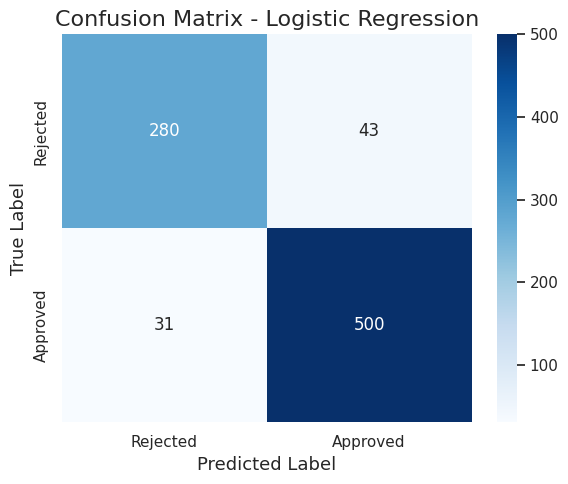

In [58]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression")

plt.tight_layout()

plt.savefig(
    "confusion_matrix_logistic_regression.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [59]:
print("="*60)
print("Logistic Regression Performance")
print("="*60)

print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1 Score : {lr_f1:.4f}")

print("="*60)

Logistic Regression Performance
Accuracy : 0.9133
Precision: 0.9208
Recall   : 0.9416
F1 Score : 0.9311


Decission Tree

In [60]:
# Initialize Decision Tree
decision_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE
)

print(decision_tree)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)


In [61]:
# Train Decision Tree
decision_tree.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [62]:
# Prediction
y_pred_dt = decision_tree.predict(X_test)

In [63]:
# Performance Metrics
dt_accuracy = accuracy_score(y_test, y_pred_dt)

dt_precision = precision_score(y_test, y_pred_dt)

dt_recall = recall_score(y_test, y_pred_dt)

dt_f1 = f1_score(y_test, y_pred_dt)

results_dt = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        dt_accuracy,
        dt_precision,
        dt_recall,
        dt_f1
    ]
})

display(results_dt)

,Metric,Score
0,Accuracy,0.974239
1,Precision,0.986616
2,Recall,0.971751
3,F1 Score,0.979127


In [64]:
# Classification Report
print(classification_report(
    y_test,
    y_pred_dt
))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       323
           1       0.99      0.97      0.98       531

    accuracy                           0.97       854
   macro avg       0.97      0.98      0.97       854
weighted avg       0.97      0.97      0.97       854



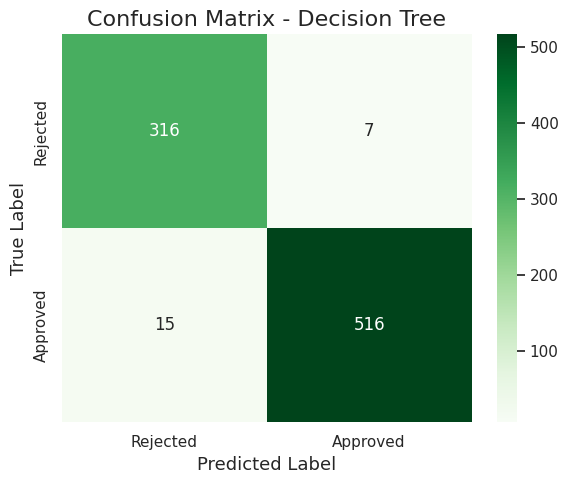

In [65]:
# Confusion Matrix
cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Rejected","Approved"],
    yticklabels=["Rejected","Approved"]
)

plt.title("Confusion Matrix - Decision Tree")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.tight_layout()

plt.savefig(
    "confusion_matrix_decision_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [66]:
print("="*60)

print("Decision Tree Performance")

print("="*60)

print(f"Accuracy : {dt_accuracy:.4f}")

print(f"Precision: {dt_precision:.4f}")

print(f"Recall   : {dt_recall:.4f}")

print(f"F1 Score : {dt_f1:.4f}")

print("="*60)

Decision Tree Performance
Accuracy : 0.9742
Precision: 0.9866
Recall   : 0.9718
F1 Score : 0.9791


In [67]:
# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": decision_tree.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
6,cibil_score,0.874059
5,loan_term,0.090204
4,loan_amount,0.023489
3,income_annum,0.010594
8,commercial_assets_value,0.000916
7,residential_assets_value,0.000738
0,no_of_dependents,0.000000
2,self_employed,0.000000
1,education,0.000000
9,luxury_assets_value,0.000000


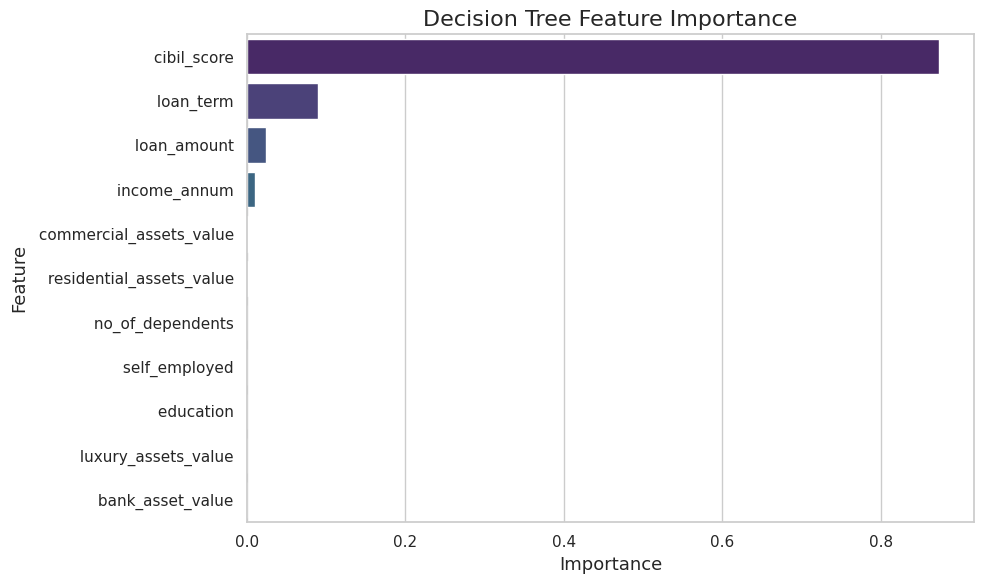

In [68]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Decision Tree Feature Importance")

plt.tight_layout()

plt.savefig(
    "decision_tree_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [69]:
#Decission Tree generalization check
print("Train Accuracy :", decision_tree.score(X_train, y_train))
print("Test Accuracy  :", decision_tree.score(X_test, y_test))

Train Accuracy : 0.9727672035139092
Test Accuracy  : 0.9742388758782201


In [70]:
# Logistic Regression Generalization Check
print("Train Accuracy :", log_reg.score(X_train_scaled, y_train))
print("Test Accuracy  :", log_reg.score(X_test_scaled, y_test))

Train Accuracy : 0.9183016105417277
Test Accuracy  : 0.9133489461358314


In [71]:
# Model Performance Comparison
comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Logistic Regression": [
        lr_accuracy,
        lr_precision,
        lr_recall,
        lr_f1
    ],
    "Decision Tree": [
        dt_accuracy,
        dt_precision,
        dt_recall,
        dt_f1
    ]
})

comparison_df = comparison_df.set_index("Metric")

display(comparison_df.round(4))

,Logistic Regression,Decision Tree
Metric,,
Accuracy,0.9133,0.9742
Precision,0.9208,0.9866
Recall,0.9416,0.9718
F1 Score,0.9311,0.9791


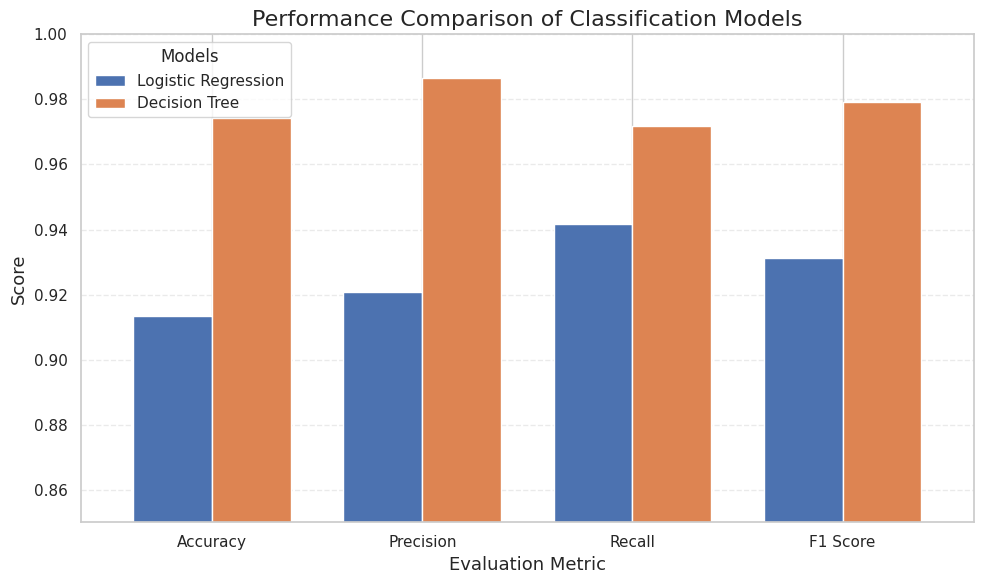

In [72]:
# Model Comparison Bar Chart
comparison_df.plot(
    kind="bar",
    figsize=(10,6),
    width=0.75
)

plt.title("Performance Comparison of Classification Models")

plt.ylabel("Score")

plt.xlabel("Evaluation Metric")

plt.ylim(0.85, 1.0)

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(title="Models")

plt.tight_layout()

plt.savefig(
    "model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [73]:
# Best Model Selection
winner = comparison_df.idxmax(axis=1)

winner_df = pd.DataFrame({
    "Metric": comparison_df.index,
    "Best Model": winner.values
})

display(winner_df)

,Metric,Best Model
0,Accuracy,Decision Tree
1,Precision,Decision Tree
2,Recall,Decision Tree
3,F1 Score,Decision Tree


In [74]:
# Overall Best Model
average_scores = comparison_df.mean(axis=0)

display(
    average_scores.to_frame(
        name="Average Score"
    ).round(4)
)

best_model = average_scores.idxmax()

print("="*60)
print(f"🏆 Overall Best Model : {best_model}")
print("="*60)

,Average Score
Logistic Regression,0.9267
Decision Tree,0.9779


🏆 Overall Best Model : Decision Tree


In [75]:
# Model Ranking
ranking = (
    average_scores
    .sort_values(ascending=False)
    .reset_index()
)

ranking.columns = [
    "Model",
    "Average Score"
]

ranking.index = ranking.index + 1

display(ranking.round(4))

,Model,Average Score
1,Decision Tree,0.9779
2,Logistic Regression,0.9267


In [76]:
#final comparison
print("="*70)
print("Final Model Performance Summary")
print("="*70)

print(comparison_df.round(4))

print("\nAverage Scores")
print("-"*70)

print(average_scores.round(4))

print("\n🏆 Best Performing Model :", best_model)

print("="*70)

Final Model Performance Summary
           Logistic Regression  Decision Tree
Metric                                       
Accuracy                0.9133         0.9742
Precision               0.9208         0.9866
Recall                  0.9416         0.9718
F1 Score                0.9311         0.9791

Average Scores
----------------------------------------------------------------------
Logistic Regression    0.9267
Decision Tree          0.9779
dtype: float64

🏆 Best Performing Model : Decision Tree


In [77]:
# Apply SMOTE on Training Data Only
smote = SMOTE(
    random_state=RANDOM_STATE
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Original Training Set")

print(y_train.value_counts())

print()

print("After SMOTE")

print(y_train_smote.value_counts())

Original Training Set
 loan_status
1    2125
0    1290
Name: count, dtype: int64

After SMOTE
 loan_status
1    2125
0    2125
Name: count, dtype: int64


In [78]:
# Scale SMOTE Data

scaler_smote = StandardScaler()

X_train_smote_scaled = scaler_smote.fit_transform(
    X_train_smote
)

X_test_scaled_smote = scaler_smote.transform(
    X_test
)

In [79]:
# Logistic Regression + SMOTE

log_reg_smote = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=1000,
    random_state=RANDOM_STATE
)

log_reg_smote.fit(
    X_train_smote_scaled,
    y_train_smote
)

y_pred_lr_smote = log_reg_smote.predict(
    X_test_scaled_smote
)

In [80]:
#evaluation
lr_smote_accuracy = accuracy_score(
    y_test,
    y_pred_lr_smote
)

lr_smote_precision = precision_score(
    y_test,
    y_pred_lr_smote
)

lr_smote_recall = recall_score(
    y_test,
    y_pred_lr_smote
)

lr_smote_f1 = f1_score(
    y_test,
    y_pred_lr_smote
)

results_lr_smote = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score":[
        lr_smote_accuracy,
        lr_smote_precision,
        lr_smote_recall,
        lr_smote_f1
    ]
})

display(results_lr_smote.round(4))

,Metric,Score
0,Accuracy,0.9192
1,Precision,0.9442
2,Recall,0.9247
3,F1 Score,0.9343


In [81]:
#Decission tree with smote
decision_tree_smote = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE
)

decision_tree_smote.fit(
    X_train_smote,
    y_train_smote
)

y_pred_dt_smote = decision_tree_smote.predict(
    X_test
)

In [82]:
#Evaluation
dt_smote_accuracy = accuracy_score(
    y_test,
    y_pred_dt_smote
)

dt_smote_precision = precision_score(
    y_test,
    y_pred_dt_smote
)

dt_smote_recall = recall_score(
    y_test,
    y_pred_dt_smote
)

dt_smote_f1 = f1_score(
    y_test,
    y_pred_dt_smote
)

results_dt_smote = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score":[
        dt_smote_accuracy,
        dt_smote_precision,
        dt_smote_recall,
        dt_smote_f1
    ]
})

display(results_dt_smote.round(4))

,Metric,Score
0,Accuracy,0.9719
1,Precision,0.9829
2,Recall,0.9718
3,F1 Score,0.9773


In [83]:
#comparison before vs after smote
comparison_smote = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Logistic Regression":[
        lr_accuracy,
        lr_precision,
        lr_recall,
        lr_f1
    ],

    "Logistic + SMOTE":[
        lr_smote_accuracy,
        lr_smote_precision,
        lr_smote_recall,
        lr_smote_f1
    ],

    "Decision Tree":[
        dt_accuracy,
        dt_precision,
        dt_recall,
        dt_f1
    ],

    "Decision Tree + SMOTE":[
        dt_smote_accuracy,
        dt_smote_precision,
        dt_smote_recall,
        dt_smote_f1
    ]

})

comparison_smote = comparison_smote.set_index("Metric")

display(
    comparison_smote.round(4)
)

,Logistic Regression,Logistic + SMOTE,Decision Tree,Decision Tree + SMOTE
Metric,,,,
Accuracy,0.9133,0.9192,0.9742,0.9719
Precision,0.9208,0.9442,0.9866,0.9829
Recall,0.9416,0.9247,0.9718,0.9718
F1 Score,0.9311,0.9343,0.9791,0.9773


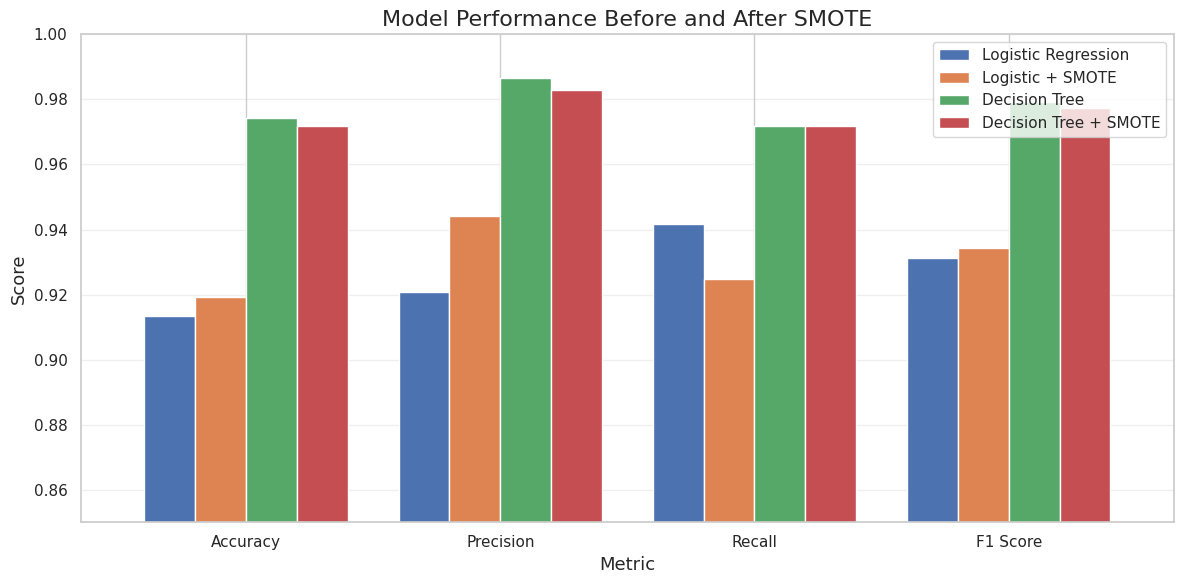

In [85]:
#Visualization
comparison_smote.plot(
    kind="bar",
    figsize=(12,6),
    width=0.8
)

plt.title("Model Performance Before and After SMOTE")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.ylim(0.85,1.0)

plt.grid(axis="y",alpha=0.3)

plt.tight_layout()

plt.savefig(
    "smote_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [86]:
# ============================================================
# Final Model Ranking
# ============================================================

# Calculate average performance of each model
average_scores = {
    "Logistic Regression": (lr_accuracy + lr_precision + lr_recall + lr_f1) / 4,
    "Logistic + SMOTE": (lr_smote_accuracy + lr_smote_precision + lr_smote_recall + lr_smote_f1) / 4,
    "Decision Tree": (dt_accuracy + dt_precision + dt_recall + dt_f1) / 4,
    "Decision Tree + SMOTE": (dt_smote_accuracy + dt_smote_precision + dt_smote_recall + dt_smote_f1) / 4,
}

# Convert to DataFrame
ranking_df = (
    pd.DataFrame(
        average_scores.items(),
        columns=["Model", "Average Score"]
    )
    .sort_values(by="Average Score", ascending=False)
    .reset_index(drop=True)
)

# Medal Icons
medals = ["🥇", "🥈", "🥉"]

ranking_df["Rank"] = [
    medals[i] if i < 3 else str(i + 1)
    for i in range(len(ranking_df))
]

# Reorder columns
ranking_df = ranking_df[
    ["Rank", "Model", "Average Score"]
]

display(ranking_df.round(4))

,Rank,Model,Average Score
0,🥇,Decision Tree,0.9779
1,🥈,Decision Tree + SMOTE,0.9759
2,🥉,Logistic + SMOTE,0.9306
3,4,Logistic Regression,0.9267


In [91]:
# Display Ranking Table
display(ranking_df.round(4))

# Save Ranking Table as CSV
ranking_df.round(4).to_csv(
    "final_model_ranking.csv",
    index=False
)

plt.show()

,Rank,Model,Average Score
0,🥇,Decision Tree,0.9779
1,🥈,Decision Tree + SMOTE,0.9759
2,🥉,Logistic + SMOTE,0.9306
3,4,Logistic Regression,0.9267
